# Training FNO for the 1D Diffusion Equation in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library. This notebook extends previous steady-state operator-learning examples (i.e. [Darcy Flow in Neuromancer](./Part_4_FNO_DarcyFlow.ipynb)) to a **time-dependent problem**. The 1D diffusion equation is solved using a **2D Fourier Neural Operator**, where time is treated as an additional spatial dimension.

### Key differences from the Darcy Flow example

- **Coordinate-based input (in_channels = 2)**  
  Unlike Darcy flow, where the input is a spatially varying coefficient field, the input here is the coordinate grid itself. The two input channels correspond to the spatial coordinate $x$ and time coordinate $t$ at each grid point.

- **2D spectral representation for a 1D PDE**  
  Although the physical domain is one-dimensional in space, the solution is defined on the space–time domain $(x, t)$. The FNO therefore operates on a 2D grid with spectral modes $n_\text{modes} = (8, 8)$, learning coupled dynamics across space and time.

- **Geometry-to-solution mapping**  
  In the Darcy example, the operator maps one field to another ($\mathbf{K} \to \mathbf{P}$). Here, the model learns a coordinate-based surrogate
  $$
  \mathcal{G}: (x, t) \mapsto y(x,t),
  $$
  directly parameterizing the solution on the space–time manifold.

Example inspiration: `examples/PDEs/Part_1_PINN_DiffusionEquation.ipynb`

We use a 16 x 16 training grid for training an FNO, and test the prediction on a 32 x 32 grid

This tutorial demonstrates the complete workflow of training a neural operator: 
1. Creating the diffusion equation dataset, wrapping in Neuromancer DictDataset
2. Creating an FNO model architecture 
3. Setting up `neuromancer.problem.Problem`, adding H1/L2 losses as `neuromancer.loss.PenaltyLoss`
4. Training the model with Neuromancer `Trainer`
5. Evaluating predictions and zero-shot super-resolution



## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Problem Setup

original source: https://deepxde.readthedocs.io/en/latest/demos/pinn_forward/diffusion.1d.html

**Diffusion equation**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}-e^{-t}(sin(\pi x)-\pi^2 sin(\pi x))$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

**Initial Condition:**

$$y(x,0)=sin(\pi x)$$

**Boundary Conditions:**

$$y(-1,t)=0$$
$$y(1,t)=0$$

**Exact solution:**

$$y(x,t)=e^{-t}sin(\pi x)$$

### Generate data of the exact solution

In [4]:
# exact solution y(x,t)
def f_real(x, t):
    return torch.exp(-t) * (torch.sin(np.pi * x))


# define range of the space and time variables:
x_min = -1
x_max = 1
t_min = 0
t_max = 1

# define number of spatial and temporal points
total_points_x = 200
total_points_t = 100

# generate samples of x, t
x = torch.linspace(x_min, x_max, total_points_x).view(-1, 1)
t = torch.linspace(t_min, t_max, total_points_t).view(-1, 1)

# Create the mesh of x, t
X, T = torch.meshgrid(x.squeeze(1), t.squeeze(1), indexing="ij")

# Evaluate exact solution y(x,t) on the mesh
y_real = f_real(X, T)

# data shapes
print(x.shape, t.shape)
print(X.shape, T.shape, y_real.shape)

torch.Size([200, 1]) torch.Size([100, 1])
torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])


In [5]:
# min and max values of the PDE solution
ymin = y_real.min()
ymax = y_real.max()
print(ymin, ymax)

tensor(-1.0000) tensor(1.0000)


### Plot the exact solution

In [6]:
def plot3D(X, T, y):
    #     2D
    fig = plt.figure()
    ax1 = fig.add_subplot(121)
    cm = ax1.contourf(T.numpy(), X.numpy(), y.numpy(), 20, cmap="viridis")
    fig.colorbar(cm, ax=ax1)  # Add a colorbar to a plot
    ax1.set_title("y(x,t)")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x")
    ax1.set_aspect("equal")
    #     3D
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.plot_surface(T.numpy(), X.numpy(), y.numpy(), cmap="viridis")
    ax2.set_xlabel("t")
    ax2.set_ylabel("x")
    ax2.set_zlabel("y(x,t)")
    fig.tight_layout()

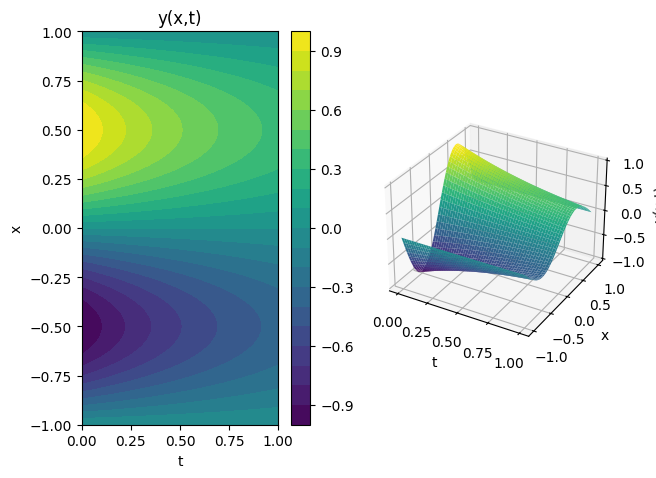

In [7]:
plot3D(X, T, y_real)

Insert training dataset for FNO, which is a sub-sampled 32x32 grid from the original 200X100 data

In [8]:
def make_fno_grid(nx, nt, requires_grad=False):
    x = torch.linspace(x_min, x_max, nx)
    t = torch.linspace(t_min, t_max, nt)
    X, T = torch.meshgrid(x, t, indexing="ij")
    Y = f_real(X, T)
    # Make grid tensors, FNO needs input shape: [batch_size, in_channels, nx, nt]
    xt_grid = torch.stack([X, T], dim=0).unsqueeze(0).float()  # [1, 2, nx, nt]
    y_grid = Y.unsqueeze(0).unsqueeze(0).float()
    # grad specified? (for training data)
    if requires_grad:
        xt_grid.requires_grad_(True)
    return xt_grid, y_grid

In [9]:
train_nx, train_nt = 16, 16
test_nx, test_nt = 32, 32

# 16x16 training grid
XT_train_grid, Y_train_grid = make_fno_grid(train_nx, train_nt, requires_grad=True)
# 32x32 testing grid
XT_test_grid, Y_test_grid = make_fno_grid(test_nx, test_nt, requires_grad=False)

### Visualise the training and testing grid. Takes a carterisan coordiante system

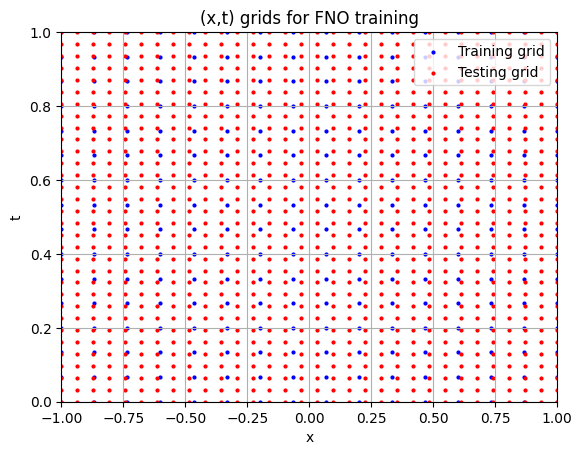

In [10]:
# visualize collocation points for 2D input space (x, t)

# --- Prepare Training Data ---
# Select the x and t coordinates (indices 0 and 1 in dim 1)
# and flatten the last two dimensions (nx * nt) into one vector.
# .squeeze() removes the batch dimension (size 1).
X_train_flat = XT_train_grid.squeeze(0)[0, :, :].flatten()
T_train_flat = XT_train_grid.squeeze(0)[1, :, :].flatten()

# --- Prepare Testing Data (assuming a similar structure) ---
X_test_flat = XT_test_grid.squeeze(0)[0, :, :].flatten()
T_test_flat = XT_test_grid.squeeze(0)[1, :, :].flatten()

# x-bounds: find the min/max ONLY in the testing x-coordinates
x_lb = torch.min(X_test_flat).item()
x_ub = torch.max(X_test_flat).item()

# t-bounds: find the min/max ONLY in the testing t-coordinates
t_lb = torch.min(T_test_flat).item()
t_ub = torch.max(T_test_flat).item()

# --- Plotting ---
plt.figure()
plt.scatter(
    X_train_flat.detach().numpy(),
    T_train_flat.detach().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="Training grid",
)
plt.scatter(
    X_test_flat.detach().numpy(),
    T_test_flat.detach().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="Testing grid",
)

plt.title("(x,t) grids for FNO training")
# Assuming x_lb, x_ub, t_lb, t_ub are defined in your environment
plt.xlim(x_lb, x_ub)
plt.ylim(t_lb, t_ub)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
# plt.show(block=True) # Usually only one plt.show() is needed
plt.show(block=True)

### Create Neuromancer datasets for FNO

In [11]:
from neuromancer.dataset import DictDataset

# turn on gradients for FNO
XT_train_grid = XT_train_grid.to(device)
Y_train_grid = Y_train_grid.to(device)

# Prepare FNO training and testing datasets
train_ds_fno = DictDataset(
    {"xt_grid": XT_train_grid, "y_grid": Y_train_grid}, name="fno_train"
)

train_loader_fno = torch.utils.data.DataLoader(
    train_ds_fno, batch_size=1, collate_fn=train_ds_fno.collate_fn, shuffle=False
)

# testing grid
test_ds_fno = DictDataset(
    {"xt_grid": XT_test_grid, "y_grid": Y_test_grid}, name="fno_test"
)
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno, batch_size=1, collate_fn=test_ds_fno.collate_fn, shuffle=False
)

### FNO added from neuralop library
May need a wrapper to provide data in the correct format


In [12]:
# wrapper for neuralop.models import FNO
from neuromancer.modules.operators import FNO
from neuralop.utils import count_model_params
import sys

# FNO to to train the operator for the PDE problem bounded in the PDE domain
fno_model = FNO(
    n_modes=(8, 8),
    in_channels=2,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
)
fno_model = fno_model.to(device)

# Count and display the number of parameters
n_params = count_model_params(fno_model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()



Our model has 48157 parameters.


In [13]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["xt_grid"], ["y_hat_fno"], name="fno_model")

In [14]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['xt_grid']
symbolic outputs of the fno_node: ['y_hat_fno']


In [15]:
# device checks
print(device)
print(train_ds_fno.datadict["y_grid"].device)
# evaluate forward pass on the train data
fno_model_out = fno_node(train_ds_fno.datadict)
fno_model_out["y_hat_fno"].shape

cuda
cuda:0


torch.Size([1, 1, 16, 16])

In [16]:
# Check shapes match (Input vs Forward Pass Output)
print(train_ds_fno.datadict["y_grid"].shape)
print(fno_model_out["y_hat_fno"].shape)

torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 16, 16])


# Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

## L2 norm

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

## H1 norm

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$

### Formulate L2 loss, H1 loss

In [17]:
from neuromancer.modules.operators import LpLoss, H1Loss
from neuromancer.constraint import Loss  # wrapper for neuromancer

h1_loss_fn = H1Loss(d=2)
l2_loss_fn = LpLoss(d=2, p=2)

h1_obj = Loss(
    ["y_hat_fno", "y_grid"],
    lambda yhat, y: h1_loss_fn(
        yhat.squeeze(1), y.squeeze(1)
    ),  # [B, 1, Nx, Nt] -> [B, Nx, Nt]
    name="h1_loss_fn",
)

l2_obj = Loss(
    ["y_hat_fno", "y_grid"],
    lambda yhat, y: l2_loss_fn(
        yhat.squeeze(1), y.squeeze(1)
    ),  # [B, 1, Nx, Nt] -> [B, Nx, Nt]
    name="l2_loss_fn",
)

### Setup FNO problem and Trainer 

In [18]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
objectives_fno = [h1_obj]  # H1 loss for training FNO
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno, grad_inference=True)

### Show problem FNO

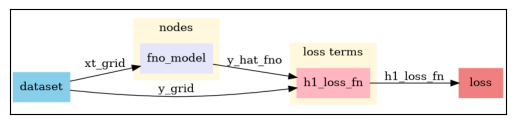

In [19]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO purely data driven

In [20]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.Adam(problem_fno.parameters(), lr=0.001)
epochs = 500

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader_fno,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="fno_train_loss",
    dev_metric="fno_train_loss",
    eval_metric="fno_train_loss",
    warmup=epochs,
    device=device,
)

In [21]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

epoch: 0  fno_train_loss: 3.0001838207244873
epoch: 10  fno_train_loss: 2.989872932434082
epoch: 20  fno_train_loss: 2.959029197692871
epoch: 30  fno_train_loss: 2.830911636352539
epoch: 40  fno_train_loss: 2.3212780952453613
epoch: 50  fno_train_loss: 1.760141372680664
epoch: 60  fno_train_loss: 1.3908988237380981
epoch: 70  fno_train_loss: 0.9881747961044312
epoch: 80  fno_train_loss: 0.7084320783615112
epoch: 90  fno_train_loss: 0.5232669711112976
epoch: 100  fno_train_loss: 0.37404665350914
epoch: 110  fno_train_loss: 0.26285669207572937
epoch: 120  fno_train_loss: 0.1943555772304535
epoch: 130  fno_train_loss: 0.1349170207977295
epoch: 140  fno_train_loss: 0.10598410665988922
epoch: 150  fno_train_loss: 0.06745417416095734
epoch: 160  fno_train_loss: 0.0569303072988987
epoch: 170  fno_train_loss: 0.04443442076444626
epoch: 180  fno_train_loss: 0.03634406626224518
epoch: 190  fno_train_loss: 0.03353668004274368
epoch: 200  fno_train_loss: 0.027341574430465698
epoch: 210  fno_train_

<All keys matched successfully>

## Plots

In [23]:
# evaluate trained PINN on test data
fno_out = problem_fno.nodes[0].cpu()
y1 = fno_out(test_ds_fno.datadict)["y_hat_fno"]

# arrange data for plotting on the test grid
y_fno = y1.reshape(shape=[test_nx, test_nt]).detach().cpu()

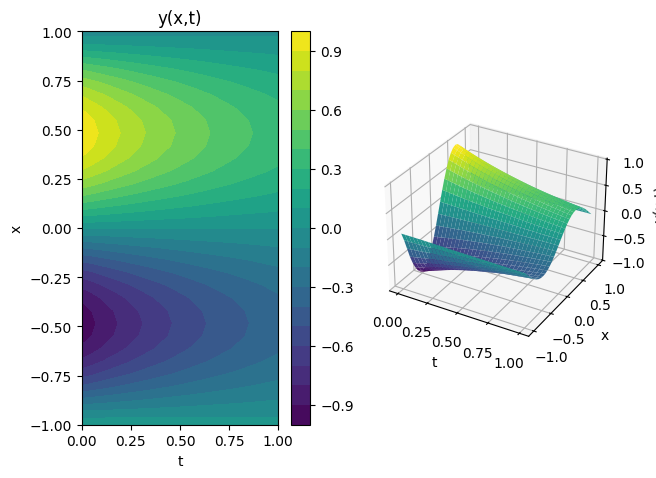

In [24]:
# plot FNO solution
# X-coordinates (index 0)
X_plot = XT_test_grid.squeeze(0)[0, :, :].detach().cpu()
# T-coordinates (index 1)
T_plot = XT_test_grid.squeeze(0)[1, :, :].detach().cpu()
plot3D(X_plot, T_plot, y_fno)

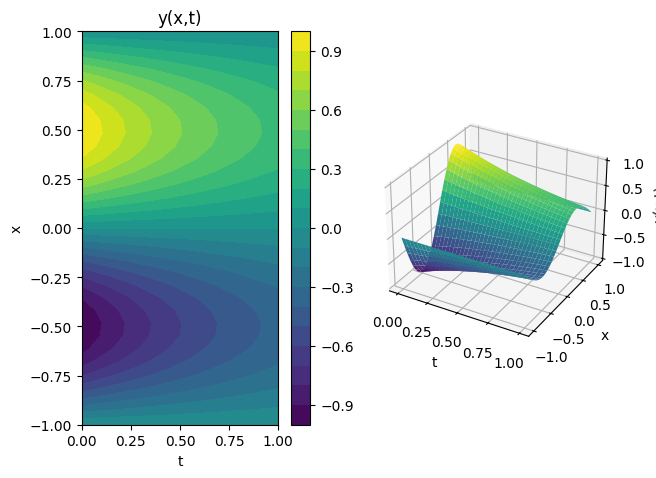

In [25]:
# plot exact PDE solution
Y_plot = Y_test_grid.squeeze(0).squeeze(0).detach().cpu()
plot3D(X_plot, T_plot, Y_plot)

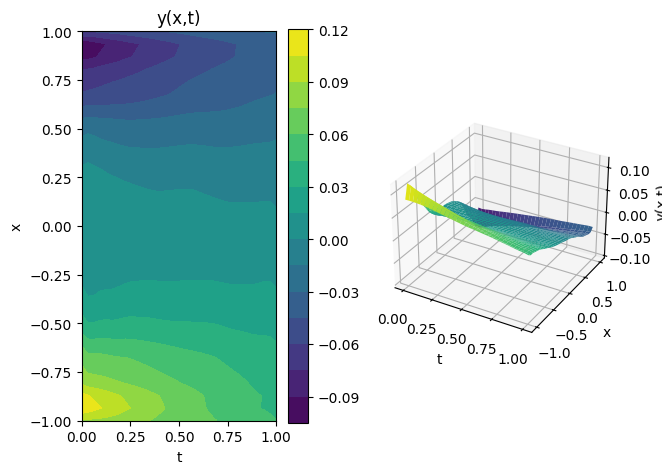

In [26]:
# plot residuals PINN - exact PDE
plot3D(X_plot, T_plot, y_fno - Y_plot)